# Time Series Training

## Reducing Granularity

In [30]:
# Step 1: Caricamento, riduzione granularità e quantizzazione
import pandas as pd

# Costante di scala da usare anche nel firmware
SCALE = 10  # Può essere anche 10 o 1000

# 1. Carica dati originali
df = pd.read_csv("smart_sensors.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df['humid'] = pd.to_numeric(df['humid'], errors='coerce')
df = df.sort_values('result_time')

# 2. Riduzione granularità (media ogni minuto)
df_resampled = df.set_index('result_time').resample('1min').mean().interpolate()

# 3. Quantizzazione (float → int16)
df_resampled['temp'] = (df_resampled['temp'] * SCALE).astype('int16')
df_resampled['humid'] = (df_resampled['humid'] * SCALE).astype('int16')

# 4. Salva il nuovo dataset quantizzato
df_resampled.to_csv("smart_sensors_quantized.csv")
print("✅ Dati granulari e quantizzati salvati su smart_sensors_quantized.csv")



/var/folders/k5/2x805v8s36zft24jm8_zy2980000gn/T/ipykernel_2368/415976556.py:8: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("smart_sensors.csv")


✅ Dati granulari e quantizzati salvati su smart_sensors_quantized.csv


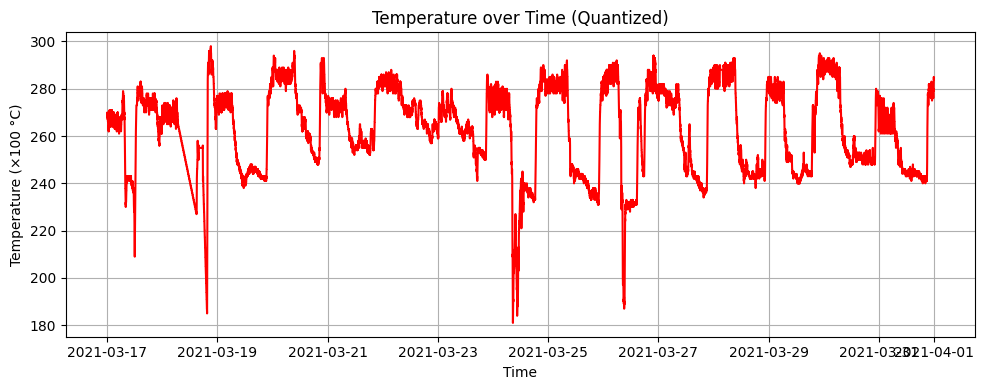

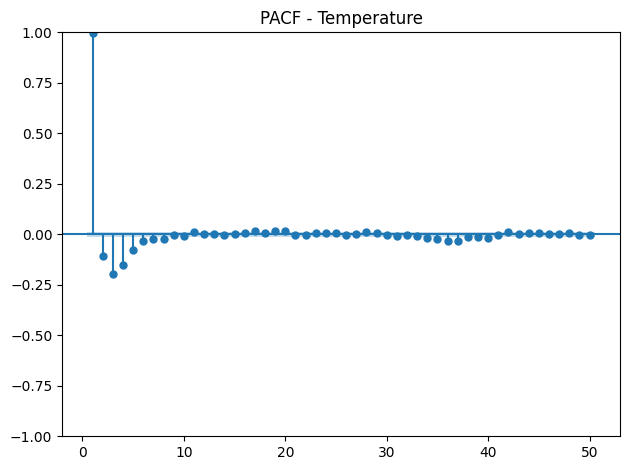

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf

df = pd.read_csv("smart_sensors_quantized.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df = df.sort_values("result_time")

max_date = df['result_time'].max()
start_date = max_date - pd.Timedelta(days=15)
df_last15 = df[df['result_time'] >= start_date]

# Grafico temperatura
plt.figure(figsize=(10, 4))
plt.plot(df_last15['result_time'], df_last15['temp'], label='Temperature', color='red')
plt.title('Temperature over Time (Quantized)')
plt.xlabel('Time')
plt.ylabel('Temperature (×100 °C)')
plt.grid(True)
plt.tight_layout()
plt.show()

# PACF
df_last15 = df_last15.set_index('result_time')
series_t = df_last15['temp']
plot_pacf(series_t.dropna(), lags=50, method='ywm', zero=False)
plt.title('PACF - Temperature')
plt.tight_layout()
plt.show()


In [32]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from math import sqrt
import joblib

# 1. Caricamento dati
df = pd.read_csv("smart_sensors_quantized.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df = df[df['result_time'] >= pd.Timestamp("2021-03-23")]
df = df.set_index('result_time')
series = df[['temp']].interpolate()

def create_lagged_features(series, n_lags, feature_name):
    X, y = [], []
    values = series[feature_name].values
    for i in range(n_lags, len(values)):
        X.append(values[i - n_lags:i])
        y.append(values[i])
    return np.array(X), np.array(y)


n_lags = 60
X, y = create_lagged_features(series, n_lags, 'temp')

# 3. Addestramento modello
model = DecisionTreeRegressor(max_depth=20, max_leaf_nodes=5000)
model.fit(X, y)

# 4. Salvataggio
joblib.dump(model, "final_temp_model.joblib")
print("✅ Modello temperatura addestrato su dati quantizzati")


✅ Modello temperatura addestrato su dati quantizzati


In [33]:
df = pd.read_csv("smart_sensors_quantized.csv")
df['result_time'] = pd.to_datetime(df['result_time'])
df = df[df['result_time'] >= pd.Timestamp("2021-03-23")]
df = df.set_index('result_time')
series = df[['humid']].interpolate()

X, y = create_lagged_features(series, n_lags, 'humid')

model = DecisionTreeRegressor(max_depth=20, max_leaf_nodes=5000)
model.fit(X, y)

joblib.dump(model, "final_humid_model.joblib")
print("✅ Modello umidità addestrato su dati quantizzati")


✅ Modello umidità addestrato su dati quantizzati


## Humidity Time Series Training & Evaluaton 

In [34]:
import joblib
from emlearn import convert

# TEMPERATURE
model1 = joblib.load("final_temp_model.joblib")
cmodel1 = convert(model1, method='inline', dtype='int16')
cmodel1.save(file='temperature_forecast_converted.h', name='temperature_forecast')
print('✅ Saved: temperature_forecast_converted.h')

# HUMIDITY
model2 = joblib.load("final_humid_model.joblib")
cmodel2 = convert(model2, method='inline', dtype='int16')
cmodel2.save(file='humidity_forecast_converted.h', name='humidity_forecast')
print('✅ Saved: humidity_forecast_converted.h')

# Macro suggerite per C
print("// MACRO da usare nel firmware:")
print("#define SCALE 10")
print("#define MIN_INPUT 0")


✅ Saved: temperature_forecast_converted.h
✅ Saved: humidity_forecast_converted.h
// MACRO da usare nel firmware:
#define SCALE 10
#define MIN_INPUT 0
